In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [9]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [10]:
print(df.shape)
print(df.columns)

(20640, 9)
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


In [11]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [13]:
coeff = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":lr.coef_
})

coeff

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [14]:
print("Intercept:", lr.intercept_)

Intercept: -37.02327770606409


In [15]:
y_pred = lr.predict(X_test)

In [16]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 0.5558915986952444
RMSE: 0.7455813830127764
MAE : 0.5332001304956553
R2  : 0.5757877060324508


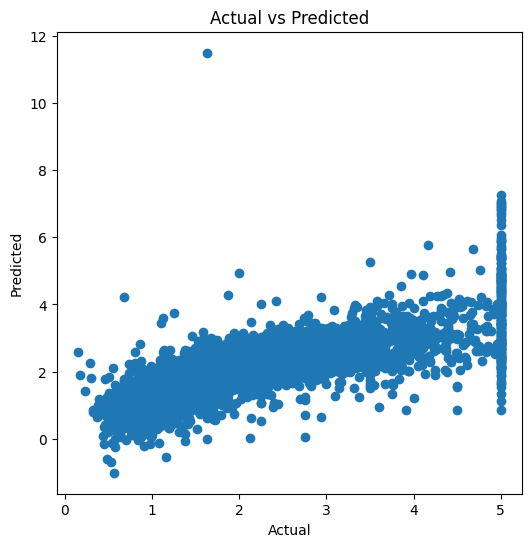

In [17]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

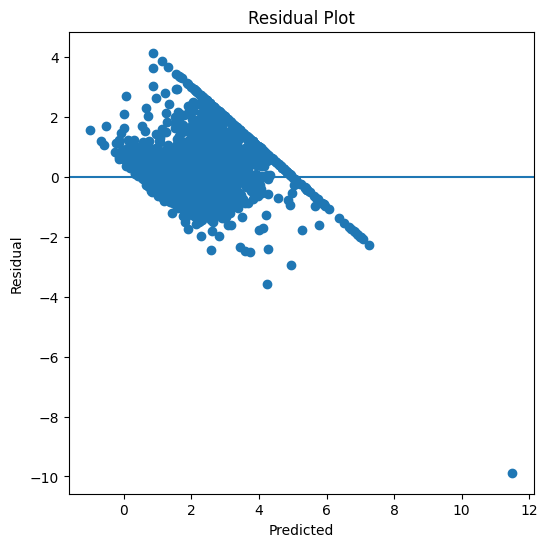

In [18]:
residuals = y_test - y_pred

plt.figure(figsize=(6,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [19]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [20]:
ridge_mse = mean_squared_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(ridge_mse)

ridge_mae = mean_absolute_error(y_test, ridge_pred)

ridge_r2 = r2_score(y_test, ridge_pred)

In [21]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_pred)

lasso_rmse = np.sqrt(lasso_mse)

lasso_mae = mean_absolute_error(y_test, lasso_pred)

lasso_r2 = r2_score(y_test, lasso_pred)

In [22]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge",
        "Lasso"
    ],

    "MSE":[
        mse,
        ridge_mse,
        lasso_mse
    ],

    "RMSE":[
        rmse,
        ridge_rmse,
        lasso_rmse
    ],

    "MAE":[
        mae,
        ridge_mae,
        lasso_mae
    ],

    "R2":[
        r2,
        ridge_r2,
        lasso_r2
    ]

})

results

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,0.555892,0.745581,0.533200,0.575788
1,Ridge,0.555803,0.745522,0.533204,0.575855
2,Lasso,0.613512,0.783270,0.581607,0.531817
